In [1]:
#%pip install torch torchaudio transformers datasets accelerate

In [2]:
#%pip uninstall tensorflow tensorflow-cpu tensorflow-gpu tf-nightly -y

In [3]:
#%pip uninstall transformers -y
#%pip install transformers

In [4]:
#%pip uninstall torchcodec -y
#%pip install "datasets<2.18.0"

In [5]:
#%pip install -U transformers accelerate datasets

In [1]:
import torch
import numpy as np
from datasets import load_dataset, Audio, Value
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.special import softmax
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

CONFIGURACIÓN

In [2]:
MODEL_NAME = "facebook/wav2vec2-base" # Nombre del modelo preentrenado
SAMPLING_RATE = 16000 # Frecuencia de muestreo - Tiene que ser 16k porque el modelo Wav2Vec2 fue entrenado con audios a esa frecuencia
NUM_LABELS = 2 # Nº de salidas del modelo
MAX_AUDIO_LEN = 10 * SAMPLING_RATE  # Duración del audio - 10 segundos

CARGA DEL DATASET

In [3]:
def cargar_carpeta(folder, label):
    data = []
    for fname in os.listdir(folder):
        if fname.endswith(".wav"):
            data.append({
                "path": os.path.join(folder, fname),
                "label": label
            })

    df = pd.DataFrame(data)
    return df

In [4]:
base = os.getcwd().rsplit("\\", 2)[0]
ruta_nat_español = 'Dataset\\Natural\\Español'
ruta_nat_ingles = 'Dataset\\Natural\\Inglés'
ruta_gen_español = 'Dataset\\Generado\\Español'
ruta_gen_ingles = 'Dataset\\Generado\\Inglés'

esp_nat = cargar_carpeta(os.path.join(base,ruta_nat_español),label=0)
ing_nat = cargar_carpeta(os.path.join(base,ruta_nat_ingles),label=0)
esp_gen = cargar_carpeta(os.path.join(base,ruta_gen_español),label=1)
ing_gen = cargar_carpeta(os.path.join(base,ruta_gen_ingles),label=1)

df = pd.concat([esp_nat, esp_gen, ing_nat, ing_gen], ignore_index=True)

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
eval_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

In [5]:
train_df.to_csv(os.path.join(base,"Dataset//todosLosAudiosMezcladosyDivididos//train.csv"), index=False)
eval_df.to_csv(os.path.join(base,"Dataset//todosLosAudiosMezcladosyDivididos//eval.csv"), index=False)
test_df.to_csv(os.path.join(base,"Dataset//todosLosAudiosMezcladosyDivididos//test.csv"), index=False)

In [11]:
train_dataset = load_dataset( # Crea un dataset dividido en 2, train y eval
    "csv",
    data_files={
        "train": os.path.join(base, "Dataset//todosLosAudiosMezcladosyDivididos//train.csv"),
        "eval": os.path.join(base, "Dataset//todosLosAudiosMezcladosyDivididos//eval.csv")
    }
)

Generating train split: 0 examples [00:00, ? examples/s]

Generating eval split: 0 examples [00:00, ? examples/s]

In [12]:
train_dataset = train_dataset.cast_column( # Cambia la columna del path del audio para cargar el audio
    "path", Audio(sampling_rate=SAMPLING_RATE)
)

In [13]:
train_dataset = train_dataset.cast_column("label", Value("int64")) # Cambia el tipo de los labels a long

Casting the dataset:   0%|          | 0/160 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

FEATURE EXTRACTOR

Define como entra el audio al modelo. Wav2Vec2FeatureExtractor recibe el audio crudo, lo normaliza, lo paddea y lo convierte al formato que espera el modelo

In [3]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_NAME, # Carga la configuración original del modelo
    sampling_rate=SAMPLING_RATE, # Fija la frecuencia de muestreo
    padding=True # El padding rellena con ceros los audios cortos y trunca los audios largos para que todos duren lo mismo
)

PREPROCESS FUNCTION

batch: audio cargado en el dataset

max_audio_len: Longitud máxima del audio

sampling_rate: Frecuencia de muestreo

feature_extractor: Feature extractor de Wav2Vec2

La función devuelve el nuevo audio tras aplicarle el feature extractor

In [15]:
from transformers import Wav2Vec2FeatureExtractor

def preprocess(batch, max_audio_len, sampling_rate, feature_extractor):
    audio = batch["path"]["array"] # Extraes el audio

    if len(audio) > max_audio_len: # Truncas el audio
        audio = audio[:max_audio_len]

    inputs = feature_extractor( # Devuelve los tensores de audio listos para el modelo
        audio,
        sampling_rate=sampling_rate,
        padding="max_length",
        max_length=max_audio_len,
        truncation=True
    )

    # Añadimos input_values
    batch["input_values"] = inputs["input_values"][0]

    return batch

# Aplicas la funcion a cada audio del dataset de entrenamiento
train_dataset = train_dataset.map(
    preprocess,
    fn_kwargs={
        "max_audio_len": MAX_AUDIO_LEN,
        "sampling_rate": SAMPLING_RATE,
        "feature_extractor": feature_extractor,
    },
    remove_columns=["path"],  # Quitas la columna path (ya no la necesitas ya que tienes input values)
    num_proc=4 # Procesamiento en paralelo para datasets grandes
)

Map (num_proc=4):   0%|          | 0/160 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/20 [00:00<?, ? examples/s]

In [16]:
print(train_dataset["train"][0].keys())

dict_keys(['label', 'input_values'])


MODEL

In [17]:
# Cargar modelo
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME, # Nombre del modelo que quieres cargar
    num_labels=NUM_LABELS, # Nº de salidas del modelo
    problem_type="single_label_classification" # Problema de clasificación binaria
)

# Congelar el feature extractor - Esto se hace para que los filtros del modelo no se sobreajusten
for param in model.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

# verificar qué se entrena
trainable = sum(p.requires_grad for p in model.parameters())
frozen = sum(not p.requires_grad for p in model.parameters())

print(f"Parámetros entrenables: {trainable}")
print(f"Parámetros congelados: {frozen}")


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parámetros entrenables: 206
Parámetros congelados: 9


METRICS

Saca las métricas de evaluación del modelo
- Precisión: verdaderos positivos / (verdaderos positivos + falsos positivos)
- Puntuación F1: Media armónica entre precisión y recall
- AUC: Mide que tan bien el modelo separa las clases real y fake 

In [6]:
def compute_metrics(pred):
    logits = pred.predictions
    labels = pred.label_ids

    probs = softmax(logits, axis=-1)
    p_fake = probs[:, 1]

    preds = (p_fake >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "auc": roc_auc_score(labels, p_fake) # Métrica que mide que tan bien se separa real de fake sin un umbral fijo
    }

TRAINING ARGS

Configuración para el entrenamiento del modelo

In [ ]:
training_args = TrainingArguments(
    output_dir="./wav2vec2-deepfake", # Carpeta que guarda los checkpoints, logs y el mejor modelo
    eval_strategy="steps", # Evaluación cada x pasos
    save_strategy="steps", # Guardado cada x pasos
    logging_steps=50, # Cada 50 pasos calcula el loss, la tasa de aprendizaje y las métricas si toca evaluar
    save_steps=500, # Evalua cada 500 pasos
    eval_steps=500, # Guarda cada 500 pasos
    learning_rate=1e-5, # Tasa de aprendizaje
    per_device_train_batch_size=4,  
    per_device_eval_batch_size=4, 
    gradient_accumulation_steps=2, 
    num_train_epochs=5, # Épocas de entrenamiento
    fp16=True, 
    load_best_model_at_end=True, # Carga el modelo con mejor métrica auc
    metric_for_best_model="auc",
    report_to="none"
)

DATA_COLLATOR

Prepara los datos justo antes de entrar al modelo

In [7]:
def data_collator(features):
    input_values = [f["input_values"] for f in features] # Recoge todos los inputs values
    labels = [f["label"] for f in features] # Recoge todas las etiquetas

    return { # Devuelve un diccionario de los datos recogidos transformados a tensores de pyTorch
        "input_values": torch.tensor(input_values, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


TRAINER

Ensambla todo el pipeline y define el entrenamiento.

In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset["train"],
    eval_dataset=train_dataset["eval"],
    data_collator=data_collator,
    processing_class=feature_extractor,
    compute_metrics=compute_metrics
)

TRAIN

In [22]:
trainer.train()

Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=100, training_loss=1.0453237533569335, metrics={'train_runtime': 4394.7798, 'train_samples_per_second': 0.182, 'train_steps_per_second': 0.023, 'total_flos': 7.262906112e+16, 'train_loss': 1.0453237533569335, 'epoch': 5.0})

Guarda el modelo entrenado

In [23]:
trainer.save_model(os.path.join(base,"Modelos//Iván//wav2vec2-deepfake-final"))
feature_extractor.save_pretrained(os.path.join(base,"Modelos//Iván//wav2vec2-deepfake-final"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['c:\\Users\\ivire\\Documents\\GitHub\\TFG\\tfg-2526-xplicavoz\\Modelos//Iván//wav2vec2-deepfake-final\\preprocessor_config.json']

Cargar modelo entrenado

In [8]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    os.path.join(base,"Modelos//Iván//wav2vec2-deepfake-final")
)
model.eval()

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


Usa el extractor de características del modelo entrenado

In [9]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    os.path.join(base,"Modelos//Iván//wav2vec2-deepfake-final")
)

Carga del dataset de prueba

In [10]:
test_dataset = load_dataset(
    "csv",
    data_files={"test": os.path.join(base,"Dataset//todosLosAudiosMezcladosyDivididos//test.csv")}
)["test"]


Generating test split: 0 examples [00:00, ? examples/s]

Probar el test con los 200 audios

In [11]:
test_dataset = load_dataset(
    "csv",
    data_files={"test": os.path.join(base,"Modelos\datos_entrenamiento_espectrogramas.csv")}
)["test"]


Generating test split: 0 examples [00:00, ? examples/s]

In [12]:
test_dataset = test_dataset.cast_column(
    "path",
    Audio(sampling_rate=16000)
)

Preprocesado del dataset de prueba - Igual que el de entrenamiento

In [13]:
SAMPLING_RATE = 16000
MAX_AUDIO_LEN = 10 * SAMPLING_RATE

def preprocess(batch, max_audio_len, sampling_rate, feature_extractor):
    audio = batch["path"]["array"]

    if len(audio) > max_audio_len:
        audio = audio[:max_audio_len]

    inputs = feature_extractor(
        audio,
        sampling_rate=sampling_rate,
        padding="max_length",
        max_length=max_audio_len,
        truncation=True
    )

    batch["input_values"] = inputs["input_values"][0]
    return batch


test_dataset = test_dataset.map(
    preprocess,
    fn_kwargs={
        "max_audio_len": MAX_AUDIO_LEN,
        "sampling_rate": SAMPLING_RATE,
        "feature_extractor": feature_extractor,
    },
    remove_columns=["path"],
    num_proc=2
)


Map (num_proc=2):   0%|          | 0/200 [00:00<?, ? examples/s]

Configuración del modelo para evaluación

In [14]:
eval_args = TrainingArguments(
    output_dir="./eval",
    per_device_eval_batch_size=4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    processing_class=feature_extractor,
    compute_metrics=compute_metrics
)

Evaluación del modelo

In [15]:
metrics = trainer.evaluate()
metrics

{'eval_loss': 0.3487932085990906,
 'eval_model_preparation_time': 0.0148,
 'eval_accuracy': 0.96,
 'eval_f1': 0.9607843137254902,
 'eval_auc': 0.98,
 'eval_runtime': 343.1386,
 'eval_samples_per_second': 0.583,
 'eval_steps_per_second': 0.146}

In [16]:
predictions = trainer.predict(test_dataset)
predictions

PredictionOutput(predictions=array([[ 0.47883075, -0.4994658 ],
       [-0.63478506,  0.5553035 ],
       [ 0.47853866, -0.4618255 ],
       [-0.7099355 ,  0.57482785],
       [-0.5997642 ,  0.5336114 ],
       [-0.6339649 ,  0.55669135],
       [ 0.49711284, -0.50349504],
       [ 0.39741707, -0.41588905],
       [ 0.4752361 , -0.46763536],
       [ 0.5131907 , -0.45240042],
       [ 0.36774242, -0.38954595],
       [ 0.49577937, -0.48309812],
       [-0.58152837,  0.5446537 ],
       [-0.6196433 ,  0.5251266 ],
       [-0.58752066,  0.5347841 ],
       [ 0.48261863, -0.47634348],
       [ 0.50459623, -0.5152814 ],
       [ 0.46236998, -0.45075577],
       [ 0.3754171 , -0.3933505 ],
       [-0.2893386 ,  0.3192943 ],
       [ 0.49542212, -0.4672933 ],
       [ 0.5270413 , -0.47284552],
       [-0.685806  ,  0.590161  ],
       [-0.59910387,  0.53491575],
       [-0.5853253 ,  0.538541  ],
       [ 0.3835179 , -0.4307697 ],
       [ 0.4374969 , -0.42195636],
       [ 0.35389534, -0.38

Post procesado de la salida

In [17]:
# Predicciones sobre el set de prueba
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
labels = predictions.label_ids

In [18]:
def logits_to_score(logits):
    x1, x2 = logits
    return 1 / (1 + np.exp(-(x2 - x1)))
    

In [19]:
scores = []
for logit in logits:
    scores.append(logits_to_score(logit))

In [23]:
test_names_dataset = load_dataset(
    "csv",
    data_files={"test": os.path.join(base,"Modelos//datos_entrenamiento_espectrogramas.csv")}
)["test"]

In [24]:
audios = []
for ruta in test_names_dataset.select_columns("path"):
    audios.append(os.path.splitext(os.path.basename(ruta["path"]))[0])

print(audios)

['I_14_N', 'I_33_G', 'I_36_N', 'E_10_G', 'I_18_G', 'I_42_G', 'E_25_N', 'E_4_N', 'I_31_N', 'I_17_N', 'I_33_N', 'E_35_N', 'E_11_G', 'E_39_G', 'I_22_G', 'E_17_N', 'E_22_N', 'I_50_N', 'E_18_N', 'E_32_G', 'I_47_N', 'I_23_N', 'I_4_G', 'I_19_G', 'I_48_G', 'E_24_N', 'I_37_N', 'E_10_N', 'I_15_G', 'I_25_G', 'E_27_G', 'E_22_G', 'I_28_G', 'E_34_N', 'I_34_G', 'I_9_N', 'E_16_N', 'E_34_G', 'E_20_N', 'E_28_N', 'I_13_G', 'I_17_G', 'E_29_G', 'E_21_G', 'E_46_N', 'E_19_N', 'I_9_G', 'E_9_G', 'I_5_N', 'I_1_G', 'I_21_N', 'E_6_G', 'E_5_N', 'I_46_G', 'I_18_N', 'E_50_N', 'E_1_G', 'I_39_N', 'I_6_N', 'E_8_N', 'E_50_G', 'I_37_G', 'E_36_N', 'I_10_N', 'E_47_N', 'E_3_N', 'I_35_G', 'E_32_N', 'I_21_G', 'I_30_N', 'I_45_N', 'E_43_N', 'E_33_G', 'I_24_G', 'I_34_N', 'E_6_N', 'I_49_G', 'I_38_N', 'E_19_G', 'I_32_G', 'I_15_N', 'E_40_N', 'E_24_G', 'I_50_G', 'I_40_G', 'E_9_N', 'I_16_N', 'I_3_G', 'I_4_N', 'E_2_G', 'I_26_N', 'I_27_G', 'I_35_N', 'I_29_G', 'I_28_N', 'I_16_G', 'I_14_G', 'E_18_G', 'E_15_N', 'E_48_N', 'I_8_N', 'E_5_G',

In [27]:
predictions.label_ids

array([0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1], dtype=int64)

In [28]:
import pandas as pd

df = pd.DataFrame({
    "audio_id": audios,
    "score": scores,
    "label_real": predictions.label_ids
})

df.to_csv("c:\\Users\\ivire\\Documents\\GitHub\\TFG\\tfg-2526-xplicavoz\\Dataset\\todosLosAudiosMezcladosyDivididos\\out.csv", index=False)


In [29]:
df

,audio_id,score,label_real
0,I_14_N,0.273230,0
1,I_33_G,0.766757,1
2,I_36_N,0.280827,0
3,E_10_G,0.783259,1
4,I_18_G,0.756461,1
...,...,...,...
195,E_2_N,0.373010,0
196,E_40_G,0.732221,1
197,E_41_G,0.776805,1
198,I_2_N,0.748454,0


Falla en 
c:\Users\ivire\Desktop\TFG\Investigacion\Datasets//Nuestro//Natural//Inglés\I_3_N.wav,0
c:\Users\ivire\Desktop\TFG\Investigacion\Datasets//Nuestro//Natural//Inglés\I_2_N.wav,0



Explicación de por que un audio real lo clasifica como que seguro es ia y viceversa

In [42]:
test_dataset

Dataset({
    features: ['label', 'input_values'],
    num_rows: 20
})

XAI para las características

In [43]:
def explain_audio(model, input_values, target_class, baseline=None, steps=50):
    """
    Compute Integrated Gradients for audio input.
    
    Args:
        model: modelo HF (ej. Wav2Vec2)
        input_values: tensor 1D (audio)
        target_class: índice de la clase a explicar
        baseline: tensor base (default = ceros)
        steps: número de pasos para la aproximación de la integral
    
    Returns:
        numpy array con las atribuciones
    """

    model.eval()

    device = next(model.parameters()).device
    input_values = input_values.to(device)

    if baseline is None:
        baseline = torch.zeros_like(input_values).to(device)

    # Escalado entre baseline y input
    scaled_inputs = [
        baseline + (float(i) / steps) * (input_values - baseline)
        for i in range(1, steps + 1)
    ]

    grads = []

    for scaled_input in scaled_inputs:
        scaled_input = scaled_input.unsqueeze(0).requires_grad_(True)

        outputs = model(input_values=scaled_input)
        logit = outputs.logits[0, target_class]

        model.zero_grad()
        logit.backward()

        grads.append(scaled_input.grad.detach())

    # Promedio de gradientes
    avg_grads = torch.mean(torch.stack(grads), dim=0)

    # Integrated gradients
    integrated_grads = (input_values - baseline) * avg_grads.squeeze(0)

    return integrated_grads.detach().cpu().numpy()


In [44]:
audio1 = torch.tensor(test_dataset[19]["input_values"])
attr1 = explain_audio(model, audio1, target_class=0)  # AUDIO QUE FALLA 

EJE X - Tiempo en milisegundos

EJE Y - Atribución -> 
- Target class = 1 - Valor positivo: Favorece predicción hacia generado. Valor negativo: Favorece predicción hacia real
- Target class = 0 - Valor positivo: Favorece predicción hacia real. Valor negativo: Favorece predicción hacia generado

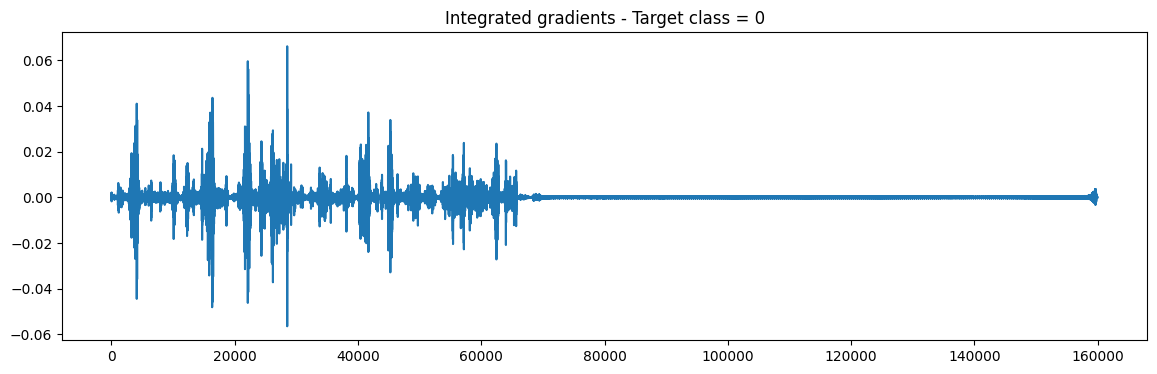

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(attr1)
plt.title("Integrated gradients - Target class = 0")
plt.show()

In [46]:
audio2 = torch.tensor(test_dataset[4]["input_values"])
attr2 = explain_audio(model,audio2,target_class=0) # AUDIO QUE ACIERTA

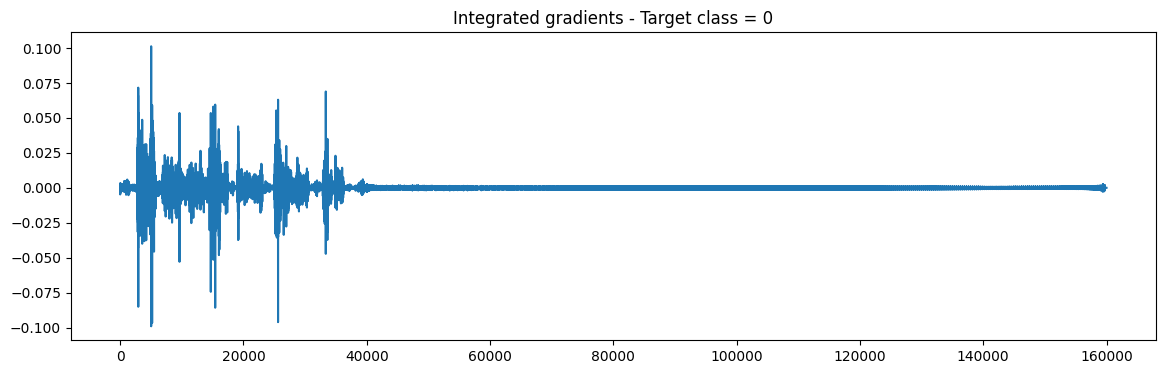

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(attr2)
plt.title("Integrated gradients - Target class = 0")
plt.show()